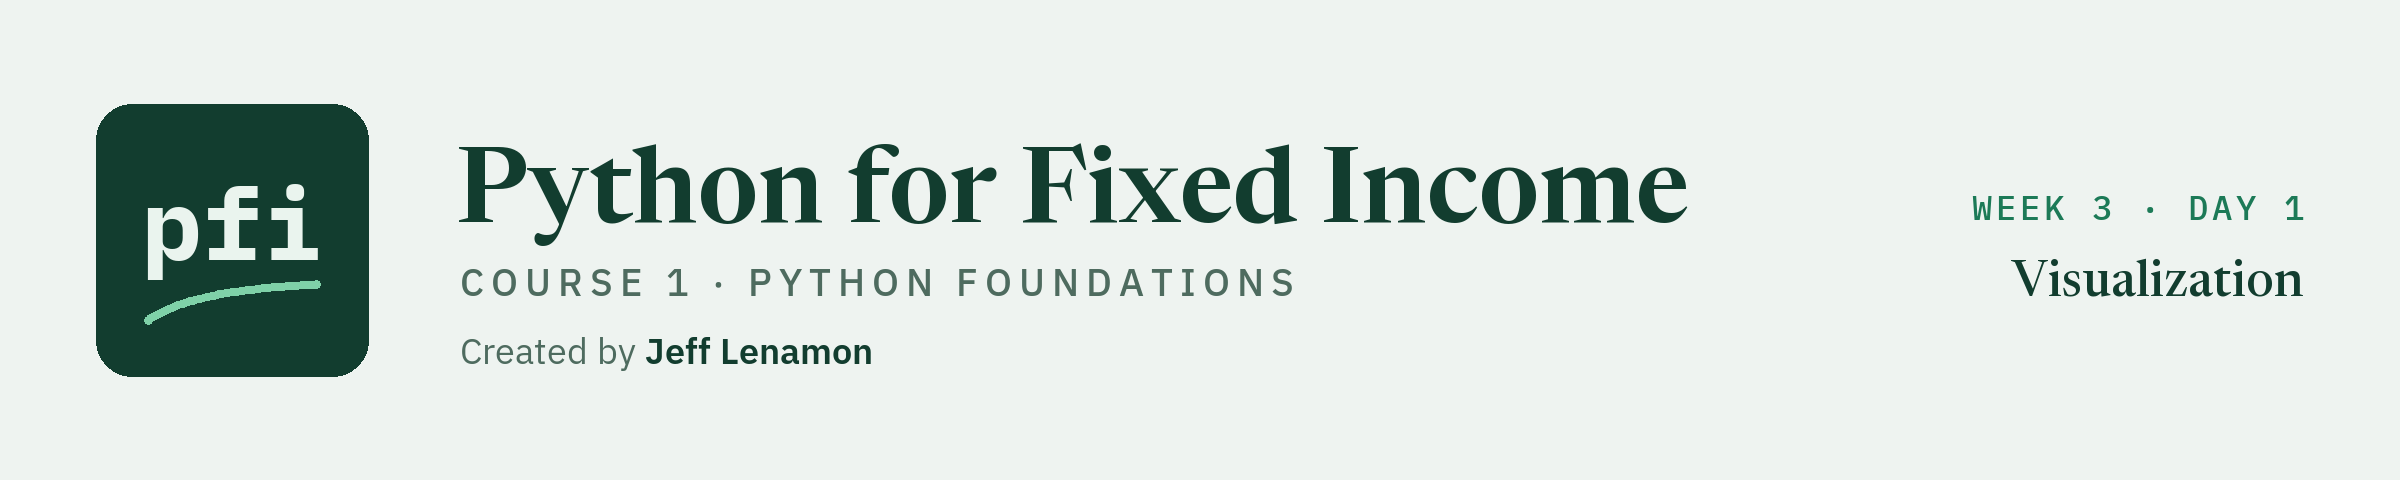

# Visualization

Week 3. Seven kinds of chart, each drawn from the desk's book, and what to read off each one.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/week3/day1/11_visualization.ipynb)

Last week ended with tables. The desk now knows the book's value by sector, its split by grade, and its average coupon. Every one of those answers was a number or a short table, and each one summarized 200 bonds in a line or two.

A summary hides things. An average spread says nothing about whether the bonds sit close to that average or far from it, and a table of 200 rows cannot be read at a glance. The portfolio manager has asked for pictures of the book: how the spreads are spread out, how they differ by rating, and which measures move together.

Two libraries draw them. **matplotlib** is the base charting library of Python. **seaborn** is built on top of it and draws common statistical charts from a table in one line. This notebook uses both, on one dataset: the 200-bond holdings file joined to the rating scale. The issuers are invented.

Every chart here describes the data. None of them says a bond or a sector is good or bad, and none suggests a trade.

## 11.1 Setting Up

Both libraries were installed when you set up the environment from `requirements.txt`. In Google Colab they are already installed.

Q. Import the libraries and check which versions are running.

In [1]:
# os is used to find the data folder
import os

# matplotlib is imported twice: once for its version number, once for its charting module
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print('pandas version:', pd.__version__)
print('matplotlib version:', matplotlib.__version__)
print('seaborn version:', sns.__version__)

pandas version: 3.0.6
matplotlib version: 3.11.2
seaborn version: 0.13.2


* `plt` is the name everyone uses for `matplotlib.pyplot`, the part of matplotlib that makes charts. `sns` is the name everyone uses for seaborn.
* This notebook was saved with the versions printed above. Yours may differ, and in Google Colab they may be older. The charts will look the same.

Q. Load the holdings and the rating scale.

In [2]:
# on your own machine the files are in the repo's data folder. In Colab they are read from GitHub.
if os.path.exists('../../data/holdings.csv'):
    data_folder = '../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

holdings = pd.read_csv(data_folder + 'holdings.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')

print('holdings:', holdings.shape)
print('ratings:', ratings.shape)

holdings: (200, 19)
ratings: (18, 4)


* 200 bonds with 19 columns, and the 18 rows of the rating scale. This is the full holdings file from the pandas notebooks. It carries the yield, the spread, and the duration, which the positions file of the case study did not.

Q. Join the rating scale to the holdings, as in the last notebook, and check that no row was lost or added.

In [3]:
# a left merge keeps every bond and looks up its score, bucket, and grade
book = pd.merge(holdings, ratings, on='rating', how='left')

print('Rows before:', holdings.shape[0], ' after:', book.shape[0])
print('Columns:', book.shape[1])
print('Bonds with no bucket:', book['bucket'].isna().sum())

Rows before: 200  after: 200
Columns: 22
Bonds with no bucket: 0


* 200 rows before and after, 22 columns, and no bond without a bucket. `book` is the one table every chart in this notebook is drawn from.

Q. Which columns will the charts use, and in what units?

In [4]:
chart_columns = ['coupon', 'price', 'yield_pct', 'oas', 'duration', 'dts', 'market_value']
book[chart_columns].describe().round(2)

,coupon,price,yield_pct,oas,duration,dts,market_value
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,5.94,98.83,6.09,185.75,6.47,1133.22,2454096.08
std,1.65,7.40,1.96,193.95,3.35,1065.70,1389340.80
min,3.25,62.04,4.09,19.00,0.93,52.20,226417.50
25%,4.75,95.14,5.06,81.75,3.88,428.82,1426338.12
50%,5.69,99.42,5.55,135.50,6.31,811.00,2295461.25
75%,6.88,103.00,6.39,213.00,8.14,1436.80,3621396.25
max,11.00,119.13,19.30,1551.00,16.04,6525.80,5435500.00


* `coupon` and `yield_pct` are in percent. `price` is the clean price per 100 of face. `oas` is the option-adjusted spread in basis points. `duration` is in years. `dts` is duration times spread. `market_value` is in dollars.
* The OAS runs from 19 to 1,551 basis points, with a mean of 185.75 and a median, the 50% row, of 135.5. Keep those four numbers in mind. The first charts are pictures of this one column.

Q. Put the seven rating buckets in credit order, for the charts that need it.

In [5]:
# sort the scale by score, then keep each bucket name the first time it appears
bucket_order = ratings.sort_values('score')['bucket'].unique().tolist()
print(bucket_order)

['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC']


* AAA first and CCC last. The order comes from the `score` column of the rating scale, so nobody typed it by hand. Last week showed what happens without it: text sorts alphabetically, and A lands before AA.

## 11.2 The Anatomy of a Chart

Every matplotlib chart has two parts, and almost every chart cell in this notebook starts with the line that makes them.

* The **figure** is the whole picture: the sheet of paper.
* The **axes** is the plot drawn on it: the rectangle with an x axis along the bottom and a y axis up the side. Titles, labels, bars, and lines all belong to the axes.

Q. Make an empty chart.

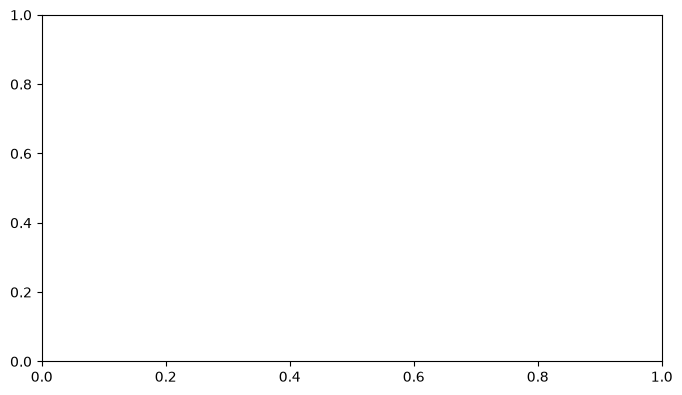

In [6]:
# plt.subplots() returns two things: the figure and the axes
# figsize is the width and the height of the figure in inches
fig, ax = plt.subplots(figsize=(8, 4.5))

# plt.show() displays the finished chart
plt.show()

* An empty rectangle with both axes running from 0 to 1. Nothing has been drawn, so matplotlib has nothing to scale the axes to.
* `fig` and `ax` are ordinary variable names, and they are the names everyone uses. From here on, a chart is built by calling methods on `ax`.
* `plt.subplots()` returns two values at once, and `fig, ax =` stores them under two names. Functions that return more than one value were covered in week 1.

Q. How many bonds are in each grade? Count them, then draw the counts as bars.

grade
Investment Grade    128
High Yield           72
Name: count, dtype: int64


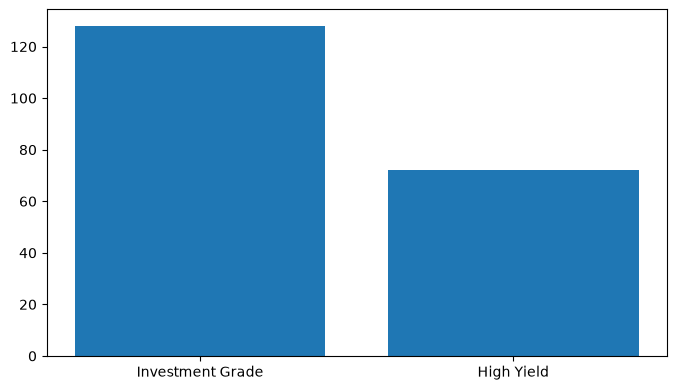

In [7]:
# count the bonds in each grade
grade_counts = book['grade'].value_counts()
print(grade_counts)

fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.bar() takes the names for the x axis and the heights of the bars
ax.bar(grade_counts.index, grade_counts.values)

plt.show()

* Two bars, 128 Investment Grade bonds and 72 High Yield bonds, the same counts as the table above them.
* The y axis now runs from 0 to a little above 128. matplotlib scaled it to fit the data.
* The chart is correct and unfinished. Handed to someone else, it does not say what is being counted. A number on an axis with no label and no unit is the charting version of a column with no header.

Q. Add a title and a label on each axis.

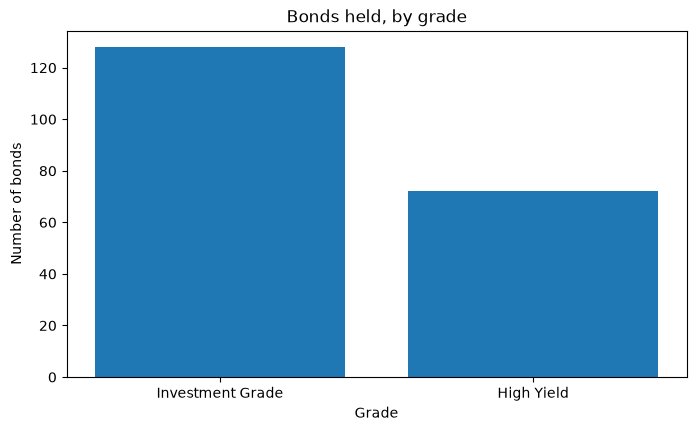

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(grade_counts.index, grade_counts.values)

# the three lines that every chart in this course carries
ax.set_title('Bonds held, by grade')
ax.set_xlabel('Grade')
ax.set_ylabel('Number of bonds')

plt.show()

* The same two bars, 128 and 72, and now the chart explains itself.
* `set_title()`, `set_xlabel()`, and `set_ylabel()` are methods of the axes. Where the axis has a unit, such as basis points or years, the unit goes in the label.
* A chart cell is built in the same order each time: make the figure and the axes, draw, label, show.

The method names have to be spelled exactly. What happens when one is not?

AttributeError: 'Axes' object has no attribute 'set_tittle'

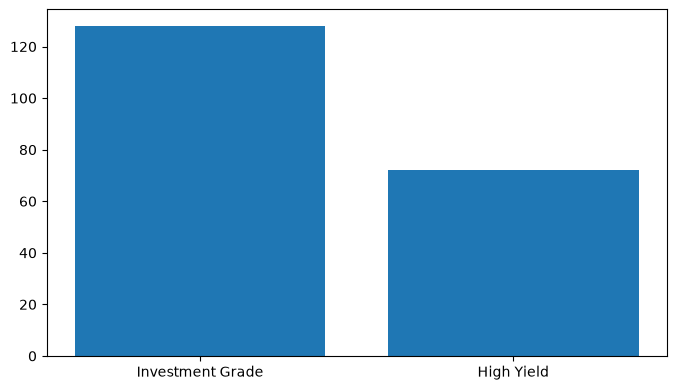

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(grade_counts.index, grade_counts.values)

# one letter too many in the method name
ax.set_tittle('Bonds held, by grade')
ax.set_xlabel('Grade')
ax.set_ylabel('Number of bonds')

plt.show()

* An `AttributeError`, and the last line says what is wrong: `'Axes' object has no attribute 'set_tittle'`. An attribute is anything that follows a dot. The axes has no method with that name, because the name is misspelled.
* The arrow in the traceback points at line 5, the line with the typo. Read the error from the bottom, as in week 1: the last line names the problem, and the arrow shows where.
* A chart still appeared under the error. Lines 1 and 2 ran before the typo was reached, so the figure had its two bars, and the notebook displayed what had been drawn so far. It has no title and no axis labels, because lines 5 to 7 never ran.
* The fix is the spelling: `set_title`. The cell above this one is the corrected version.

**Excel side by side.** In Excel a chart starts from a selected range and the Insert tab. The parts have the same jobs under different names:

| Part of the chart | matplotlib | Excel |
| --- | --- | --- |
| The whole picture | the figure, `fig` | the Chart Area |
| The plot itself | the axes, `ax` | the Plot Area |
| Title | `ax.set_title('...')` | Chart Elements, Chart Title |
| Axis labels | `ax.set_xlabel('...')`, `ax.set_ylabel('...')` | Chart Elements, Axis Titles |
| Size | `figsize=(8, 4.5)`, in inches | drag a corner of the chart |
| The counts behind the bars | `book['grade'].value_counts()` | `=COUNTIF(V:V, "High Yield")` |

Chart Elements is the plus sign that appears beside a selected chart. The formula assumes the joined table is on a sheet with the grade in column V. In Excel the chart is built by clicking, and in matplotlib the same choices are written down, so the chart can be drawn again tomorrow on a new file.

## 11.3 Histogram

A **histogram** shows how the values of one numeric column are distributed. It cuts the range of the column into equal intervals, called **bins**, counts the values that fall in each, and draws one bar per bin. A desk uses it to see the shape of a column: where most of the bonds sit, and how far the extremes reach.

Q. How are the 200 OAS values distributed?

Bonds with an OAS below 250 bp: 164
Bonds with an OAS above 500 bp: 12


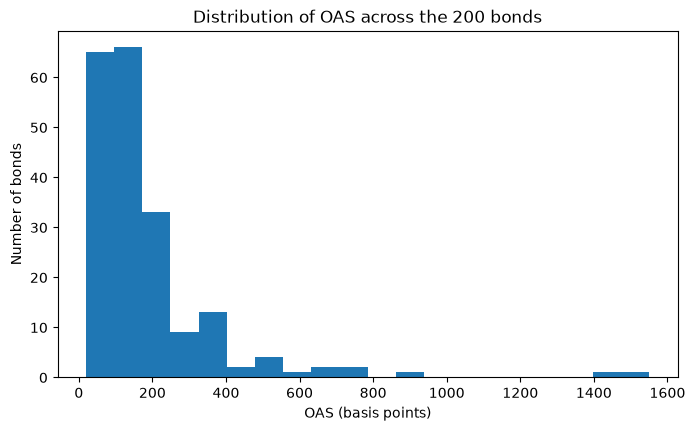

In [10]:
# two counts to check the chart against
print('Bonds with an OAS below 250 bp:', (book['oas'] < 250).sum())
print('Bonds with an OAS above 500 bp:', (book['oas'] > 500).sum())

fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.hist() takes one column. bins= is the number of intervals.
ax.hist(book['oas'], bins=20)

ax.set_title('Distribution of OAS across the 200 bonds')
ax.set_xlabel('OAS (basis points)')
ax.set_ylabel('Number of bonds')

plt.show()

* Read a histogram from the x axis up. Each bar covers a range of OAS, and its height is the number of bonds in that range.
* The tall bars are all on the left: 164 of the 200 bonds have an OAS below 250 basis points. To the right the bars are short and then stop, with a few isolated bars far out. Only 12 bonds are above 500 basis points, and the widest is at 1,551.
* This shape, a crowd on one side and a long thin tail on the other, is called **skewed**. Here the tail is on the right.

**Predict 1**

The distribution has a long tail to the right. The median OAS is the middle bond: half the bonds are below it and half above.

```
print(book['oas'].mean())
print(book['oas'].median())
```

Which is larger?

> A) The mean. The few very wide bonds pull it up.
>
> B) The median. Most of the bonds are on the left.
>
> C) They are equal. Both are the centre of the same column.

Decide, then run the cell.

Mean OAS: 185.75
Median OAS: 135.5


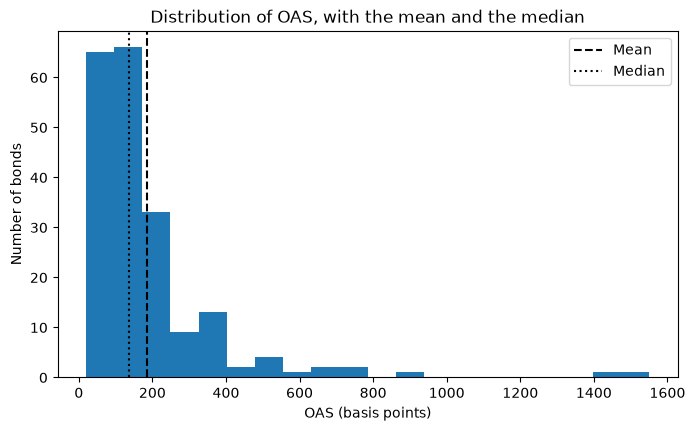

In [11]:
mean_oas = book['oas'].mean()
median_oas = book['oas'].median()
print('Mean OAS:', mean_oas)
print('Median OAS:', median_oas)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(book['oas'], bins=20)

# axvline() draws a vertical line at a value on the x axis. label= names it for the legend.
ax.axvline(mean_oas, color='black', linestyle='--', label='Mean')
ax.axvline(median_oas, color='black', linestyle=':', label='Median')

# legend() draws the box that says which line is which
ax.legend()

ax.set_title('Distribution of OAS, with the mean and the median')
ax.set_xlabel('OAS (basis points)')
ax.set_ylabel('Number of bonds')

plt.show()

* The answer is A. The mean is 185.75 basis points and the median is 135.5, about 50 basis points lower.
* The median only counts positions: the bond at 1,551 is one bond above the middle, the same as a bond at 140. The mean adds up the values, so each very wide bond pulls it to the right.
* On a skewed column, quote the median, or quote both and say which is which. The dashed line sits to the right of the dotted line, in the direction of the tail.

Q. What does the number of bins change? Draw the same column with 5 bins.

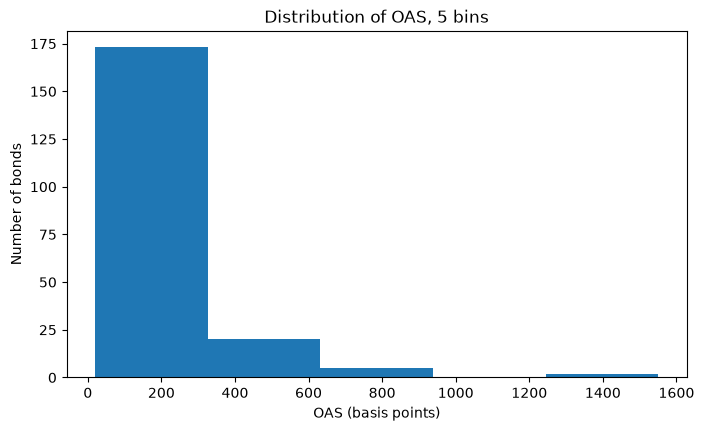

Bonds in each bin: [173.  20.   5.   0.   2.]
Edges of the bins: [  19.   325.4  631.8  938.2 1244.6 1551. ]


In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.hist() also returns what it drew: the counts, the edges of the bins, and the bars
counts, edges, bars = ax.hist(book['oas'], bins=5)

ax.set_title('Distribution of OAS, 5 bins')
ax.set_xlabel('OAS (basis points)')
ax.set_ylabel('Number of bonds')

plt.show()

print('Bonds in each bin:', counts)
print('Edges of the bins:', edges)

* With 5 bins each bar is 306.4 basis points wide, and the first one, from 19 to 325.4, holds 173 of the 200 bonds. The fourth bin is empty and the fifth holds the 2 widest bonds.
* The data is the same and the picture is not. Five bins hide everything that happens below 325 basis points, which is where most of the book is. With 20 bins each bar was 76.6 basis points wide and the crowd on the left had a shape.
* There is no correct number of bins. Too few hides the shape, and too many leaves bars of one or two bonds. Try a few and keep the one that shows the shape without the noise.

seaborn draws the same chart from the table and a column name.

Q. Draw the 20-bin histogram with seaborn.

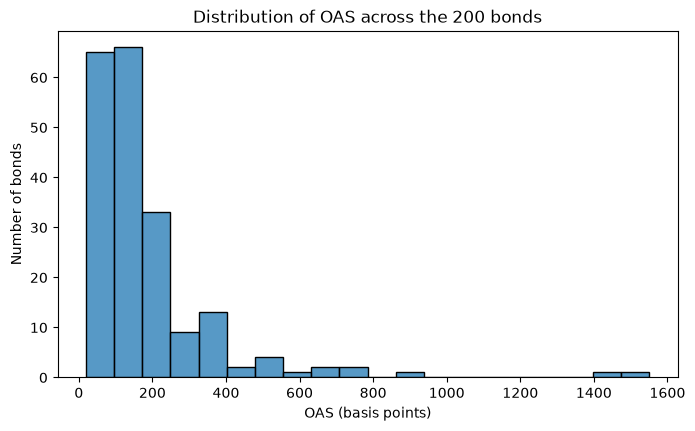

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# data= is the table, x= is the name of the column, ax= is the axes to draw on
sns.histplot(data=book, x='oas', bins=20, ax=ax)

ax.set_title('Distribution of OAS across the 200 bonds')
ax.set_xlabel('OAS (basis points)')
ax.set_ylabel('Number of bonds')

plt.show()

* The same 20 bars as the first histogram, with a thin outline on each.
* The pattern is the one every seaborn call in this notebook follows: pass the whole table as `data=`, name the columns as text, and pass `ax=ax` so the chart lands on the axes made in the line above. The title and labels are still set on `ax`.
* seaborn would label the x axis `oas` and the y axis `Count` by itself. The three label lines replace those with words and a unit.

The column name has to exist in the table. Someone used to calling this figure the spread might write:

ValueError: Could not interpret value `spread` for `x`. An entry with this name does not appear in `data`.

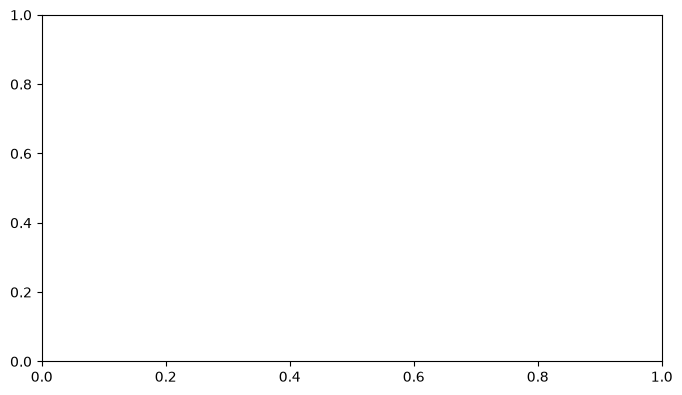

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# the column is called oas, not spread
sns.histplot(data=book, x='spread', bins=20, ax=ax)

plt.show()

* A `ValueError`, at the end of a long traceback. Most of those lines are seaborn's own code, on the way from `histplot()` down to the line that gave up. Go straight to the bottom: ``Could not interpret value `spread` for `x`. An entry with this name does not appear in `data`.``
* seaborn looked for a column named `spread` in the table and did not find one. The desk says spread and the file says `oas`.
* The empty chart under the error is the axes made on line 1. Nothing was drawn on it.
* The cure is the one from last week: print `book.columns.tolist()` and read the names. The cell before this one, with `x='oas'`, is the corrected version.

**Excel side by side.**

| Job | Python | Excel |
| --- | --- | --- |
| Histogram | `ax.hist(book['oas'], bins=20)` | select the column, then Insert, Insert Statistic Chart, Histogram (Excel 2016 and later) |
| Bonds in one bin | `counts[0]` | `=COUNTIFS(M:M, ">=19", M:M, "<325.4")` |
| Mean and median | `book['oas'].mean()`, `book['oas'].median()` | `=AVERAGE(M2:M201)`, `=MEDIAN(M2:M201)` |

The formulas assume the OAS is in column M, where it is when the holdings file is opened in Excel. The `COUNTIFS` formula returns 173, the first of the five counts above. In Excel the bin width is set in Format Axis. In matplotlib it follows from `bins=`.

## 11.4 Box Plot

A **box plot** draws five numbers of a column in one shape: the lowest value, the first quartile, the median, the third quartile, and the highest value. A desk uses it to compare the spread of a measure across groups, side by side, where a row of histograms would be too much to take in.

Q. What are the quartiles of the OAS?

In [15]:
# quantile(0.25) is the value a quarter of the way up the sorted column
q1 = book['oas'].quantile(0.25)
q3 = book['oas'].quantile(0.75)

print('Lowest:', book['oas'].min())
print('First quartile:', q1)
print('Median:', book['oas'].median())
print('Third quartile:', q3)
print('Highest:', book['oas'].max())

Lowest: 19
First quartile: 81.75
Median: 135.5
Third quartile: 213.0
Highest: 1551


* A quarter of the bonds have an OAS below 81.75 basis points, half are below 135.5, and three quarters are below 213. The middle half of the book sits between 81.75 and 213.
* The distance between the two quartiles, 213 minus 81.75, is the **interquartile range**, or IQR.

A box plot draws a box from the first quartile to the third, with a line across it at the median. From each end of the box a line called a **whisker** reaches out to the furthest value that is within 1.5 times the IQR of the box. Any value further out than that is drawn as a separate point.

Q. How far can the upper whisker reach?

In [16]:
iqr = q3 - q1

# the furthest a whisker may reach: one and a half times the IQR beyond the box
upper_limit = q3 + 1.5 * iqr
lower_limit = q1 - 1.5 * iqr

print('IQR:', iqr)
print('Upper limit:', upper_limit)
print('Lower limit:', lower_limit)

IQR: 131.25
Upper limit: 409.875
Lower limit: -115.125


* The IQR is 131.25 basis points. The upper limit is 409.875 and the lower limit is below zero, at -115.125.

**Predict 2**

The highest OAS in the book is 1,551 basis points and the upper limit is 409.875.

```
ax.boxplot(book['oas'])
```

Where does the upper whisker end?

> A) At 1,551, the highest value in the column.
>
> B) At 409.875, the limit.
>
> C) At the largest OAS in the book that is no higher than 409.875.

Decide, then run the cell.

Largest OAS within the limit: 401
Bonds beyond the limit: 14
Lowest and highest of them: 418 and 1551


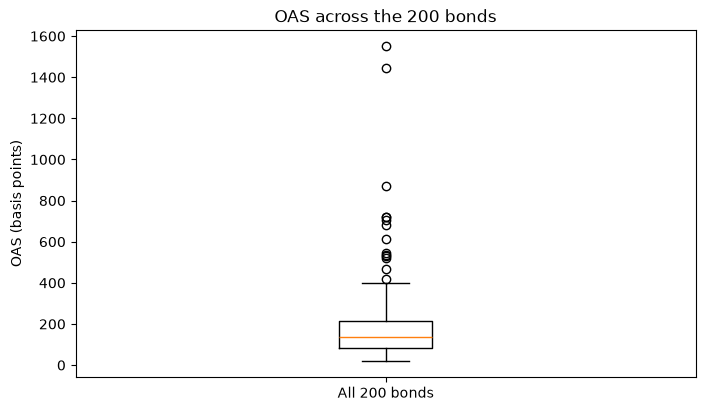

In [17]:
# the bonds beyond the upper limit
beyond = book[book['oas'] > upper_limit]

print('Largest OAS within the limit:', book.loc[book['oas'] <= upper_limit, 'oas'].max())
print('Bonds beyond the limit:', len(beyond))
print('Lowest and highest of them:', beyond['oas'].min(), 'and', beyond['oas'].max())

fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.boxplot() takes one column. tick_labels= names the box on the x axis.
ax.boxplot(book['oas'], tick_labels=['All 200 bonds'])

ax.set_title('OAS across the 200 bonds')
ax.set_ylabel('OAS (basis points)')

plt.show()

* The answer is C. The whisker ends at 401 basis points, the largest OAS in the book that is within the limit. A whisker always ends on a real bond, not on the limit itself.
* Read the chart from the bottom. The lower whisker starts at 19, the lowest OAS, because no bond is below the lower limit. The box runs from 81.75 to 213. The line inside it is the median, 135.5. The upper whisker ends at 401.
* The 14 circles above the whisker are the 14 bonds beyond the limit, from 418 up to 1,551. The histogram showed the same bonds as a thin tail.
* matplotlib calls those points fliers, and they are often called outliers. That is a drawing rule and nothing more. A point beyond the whisker is a bond whose OAS is far from the middle half of this book. The chart does not say the number is wrong, and it does not say anything about the bond.

A single box says little that the histogram did not. The box plot is useful when several are drawn side by side.

Q. Before the chart, what are the five numbers for each grade?

In [18]:
book.groupby('grade')['oas'].describe()

,count,mean,std,min,25%,50%,75%,max
grade,,,,,,,,
High Yield,72.0,339.375000,254.479609,125.0,205.25,250.5,368.00,1551.0
Investment Grade,128.0,99.335938,42.800816,19.0,66.00,95.0,129.75,204.0


* 72 High Yield bonds with a median OAS of 250.5 basis points, and 128 Investment Grade bonds with a median of 95. The 25%, 50%, and 75% columns are the three lines of each box.

Q. Draw one box for each grade.

High Yield upper limit: 612.125
Largest High Yield OAS within it: 547
High Yield bonds beyond it: 8


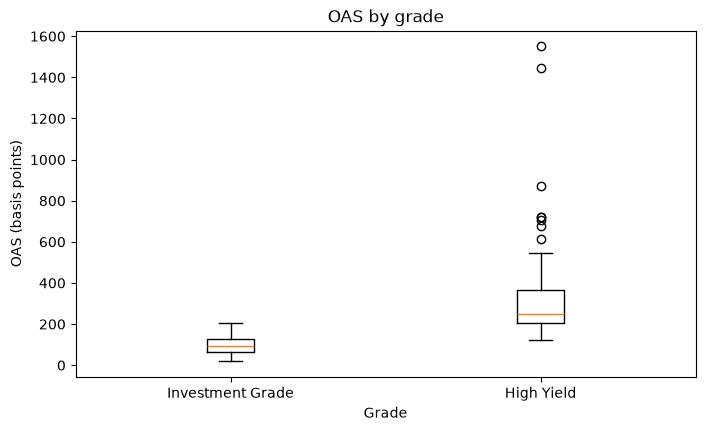

In [19]:
# the OAS column, split into the two grades
ig_oas = book.loc[book['grade'] == 'Investment Grade', 'oas']
hy_oas = book.loc[book['grade'] == 'High Yield', 'oas']

# the upper limit of the High Yield box, worked out from its own quartiles
hy_q1 = hy_oas.quantile(0.25)
hy_q3 = hy_oas.quantile(0.75)
hy_limit = hy_q3 + 1.5 * (hy_q3 - hy_q1)
print('High Yield upper limit:', hy_limit)
print('Largest High Yield OAS within it:', hy_oas[hy_oas <= hy_limit].max())
print('High Yield bonds beyond it:', (hy_oas > hy_limit).sum())

fig, ax = plt.subplots(figsize=(8, 4.5))

# a list of columns gives one box each, in the order of the list
ax.boxplot([ig_oas, hy_oas], tick_labels=['Investment Grade', 'High Yield'])

ax.set_title('OAS by grade')
ax.set_xlabel('Grade')
ax.set_ylabel('OAS (basis points)')

plt.show()

* The Investment Grade box is low and short: the middle half of those bonds is between 66 and 129.75 basis points, the whiskers run from 19 to 204, and there are no points beyond them.
* The High Yield box is higher and taller: the middle half is between 205.25 and 368 basis points, around a median of 250.5. Its upper whisker ends at 547, and 8 bonds are drawn beyond it.
* The two boxes do not overlap. The third quartile of the Investment Grade bonds, 129.75, is below the first quartile of the High Yield bonds, 205.25. The whiskers do overlap: the lowest High Yield OAS is 125 and the highest Investment Grade OAS is 204.
* Each box has its own limits, worked out from its own quartiles. The upper limit of the High Yield box is 612.125 basis points, against 409.875 for the whole book. The 14 points beyond the whisker in the first box plot were all above 409.875, so all are High Yield bonds, and against the High Yield box only 8 of them are still beyond it.

Q. Draw one box for each rating bucket, in credit order. First the numbers.

In [20]:
# loc with the ordered list puts the rows in credit order
book.groupby('bucket')['oas'].describe().loc[bucket_order]

,count,mean,std,min,25%,50%,75%,max
bucket,,,,,,,,
AAA,2.0,21.000000,2.828427,19.0,20.00,21.0,22.00,23.0
AA,8.0,37.625000,10.861959,22.0,30.75,38.5,42.50,57.0
A,56.0,79.410714,26.902367,44.0,58.00,75.5,95.75,151.0
BBB,62.0,127.822581,35.466227,66.0,97.25,126.5,152.50,204.0
BB,49.0,226.224490,61.530909,125.0,181.00,218.0,266.00,367.0
B,18.0,503.333333,276.602709,236.0,355.25,409.5,534.25,1446.0
CCC,5.0,858.000000,406.040638,547.0,614.00,707.0,871.00,1551.0


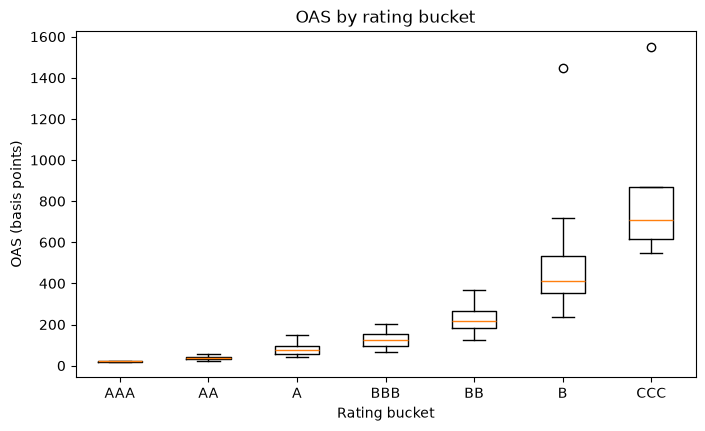

In [21]:
# one OAS column per bucket, built with a list comprehension from week 1
oas_by_bucket = [book.loc[book['bucket'] == bucket, 'oas'] for bucket in bucket_order]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot(oas_by_bucket, tick_labels=bucket_order)

ax.set_title('OAS by rating bucket')
ax.set_xlabel('Rating bucket')
ax.set_ylabel('OAS (basis points)')

plt.show()

* The median line steps up from left to right: 21 basis points for AAA, 38.5 for AA, 75.5 for A, 126.5 for BBB, 218 for BB, 409.5 for B, and 707 for CCC.
* The boxes also get taller. The middle half of the A bucket spans 58 to 95.75, a range of about 38 basis points. The middle half of the B bucket spans 355.25 to 534.25, a range of 179. In this book the lower buckets have wider spreads and a wider range of spreads.
* Two points are drawn beyond a whisker: the B bond at 1,446 and the CCC bond at 1,551. Those two bonds stretch the y axis, which is why the five boxes on the left look flat.
* Count before reading a box. The AAA box is drawn from 2 bonds and the CCC box from 5. A box drawn from 2 bonds has the same outline as one drawn from 62, and the `count` column of the table is the only place that shows the difference.

**Excel side by side.**

| Job | Python | Excel |
| --- | --- | --- |
| Box plot | `ax.boxplot(book['oas'])` | select the column, then Insert, Insert Statistic Chart, Box and Whisker (Excel 2016 and later) |
| First quartile | `book['oas'].quantile(0.25)` | `=QUARTILE.INC(M2:M201, 1)` |
| Median | `book['oas'].median()` | `=MEDIAN(M2:M201)` |
| Third quartile | `book['oas'].quantile(0.75)` | `=QUARTILE.INC(M2:M201, 3)` |
| One box per group | a list of columns | select the group column with the value column before inserting the chart |

`QUARTILE.INC` returns 81.75 and 213, the same quartiles as pandas. Excel's Box and Whisker chart has its own setting for how the quartiles are calculated, so the edges of its box can differ a little from the formula and from the chart above.

## 11.5 Bar Chart

A **bar chart** draws one bar for each category, with the height of the bar showing a number for that category: a count, a total, or an average. It looks like a histogram and answers a different question. A histogram splits one numeric column into ranges. A bar chart compares named groups. A desk uses it for anything that comes out of a `groupby`.

Q. What is the average OAS of each rating bucket, in credit order?

In [22]:
# the mean OAS of each bucket, with the rows put in credit order
mean_by_bucket = book.groupby('bucket')['oas'].mean().loc[bucket_order]
print(mean_by_bucket.round(2))

bucket
AAA     21.00
AA      37.62
A       79.41
BBB    127.82
BB     226.22
B      503.33
CCC    858.00
Name: oas, dtype: float64


* Seven averages, from 21 basis points for AAA to 858 for CCC. The BBB bucket averages 127.82 basis points.

Q. Draw them as bars, with the value written on each bar.

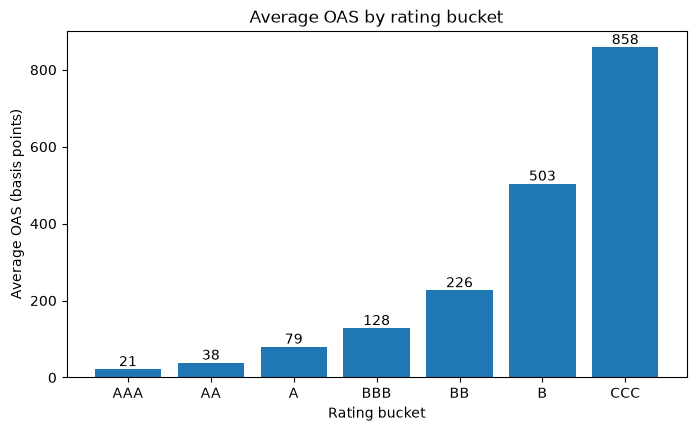

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# the index of the grouped result holds the bucket names, and the values are the heights
bars = ax.bar(mean_by_bucket.index, mean_by_bucket.values)

# bar_label() writes each height above its bar. fmt='%.0f' shows no decimal places.
ax.bar_label(bars, fmt='%.0f')

ax.set_title('Average OAS by rating bucket')
ax.set_xlabel('Rating bucket')
ax.set_ylabel('Average OAS (basis points)')

plt.show()

* Each bar is taller than the one to its left: 21, 38, 79, 128, 226, 503, and 858 basis points. The steps grow as well. From A to BBB the average rises by about 48 basis points, and from B to CCC by about 355.
* The bars are in credit order because the table was put in credit order before it was drawn. `ax.bar()` draws the rows in the order it is given them.
* Compare this with the box plots of section 11.4. The bar for B says 503, and the median of the B bucket was 409.5. A bar of averages shows one number per group and nothing about the bonds behind it. The B average is pulled up by the bond at 1,446.

seaborn can go from the table to the bars in one line. It does the grouping and the averaging itself.

**Predict 3**

```
sns.barplot(data=book, x='bucket', y='oas', errorbar=None, ax=ax)
```

The first three rows of the book are in the buckets BBB, B, and BB. In what order will the seven bars be drawn?

> A) AAA, AA, A, BBB, BB, B, CCC: credit order.
>
> B) A, AA, AAA, B, BB, BBB, CCC: alphabetical order, as `groupby` gives.
>
> C) BBB, B, BB, A, and so on: the order in which the buckets first appear in the table.

Decide, then run the cell.

['BBB', 'B', 'BB', 'A', 'AAA', 'AA', 'CCC']


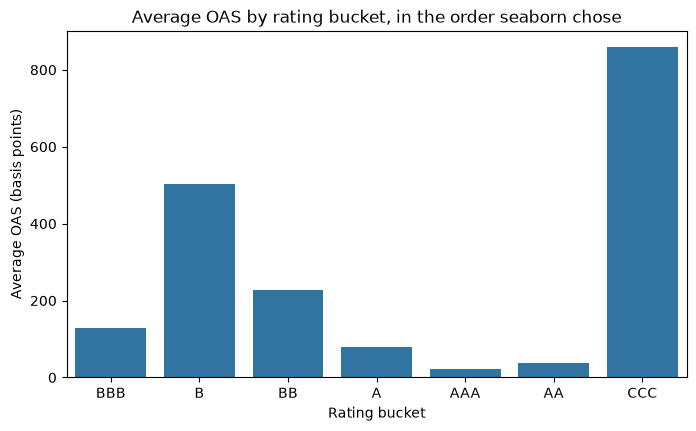

In [24]:
# the buckets in the order they first appear going down the table
print(book['bucket'].unique().tolist())

fig, ax = plt.subplots(figsize=(8, 4.5))

# barplot() averages y within each value of x. errorbar=None leaves off the range lines it adds by default.
sns.barplot(data=book, x='bucket', y='oas', errorbar=None, ax=ax)

ax.set_title('Average OAS by rating bucket, in the order seaborn chose')
ax.set_xlabel('Rating bucket')
ax.set_ylabel('Average OAS (basis points)')

plt.show()

* The answer is C: BBB, B, BB, A, AAA, AA, CCC. seaborn draws the categories of a text column in the order it meets them going down the table. The first bond is a BBB, so BBB is the first bar.
* Every bar has the right height and the right label. The order is the problem. A reader expects a rating axis to run from high to low, and may read the shape of the chart without reading the labels.
* That makes three orders for one column: alphabetical from `groupby`, first appearance from seaborn, and credit order, which is the only one a desk wants. Neither library knows that ratings have an order. It has to be passed in.

Q. Draw the same chart in credit order.

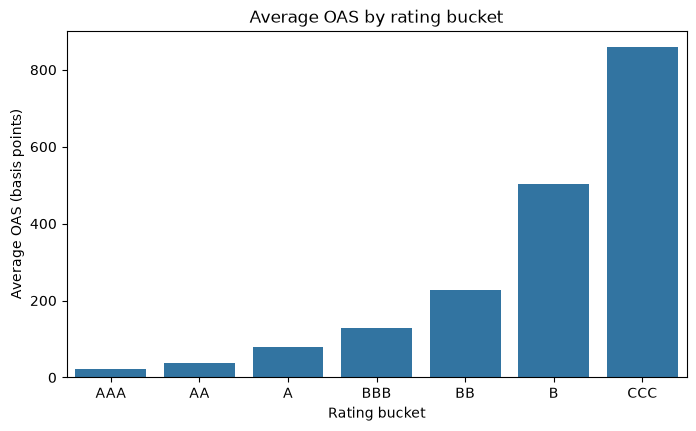

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# order= lists the categories in the order to draw them
sns.barplot(data=book, x='bucket', y='oas', order=bucket_order, errorbar=None, ax=ax)

ax.set_title('Average OAS by rating bucket')
ax.set_xlabel('Rating bucket')
ax.set_ylabel('Average OAS (basis points)')

plt.show()

* The same seven bars as the matplotlib chart, from 21 basis points for AAA up to 858 for CCC, with no `groupby` written.
* `order=bucket_order` is the argument to remember. Most seaborn functions that draw categories accept it.

Long category names fit better down the side than along the bottom.

Q. How much market value is in each sector, in millions of dollars? Draw it with the largest sector at the top.

sector
Utilities         29.01
Technology        30.31
Energy            38.83
Health Care       38.91
Transportation    48.82
Industrials       52.54
Telecom           55.85
Consumer          56.63
Financials        68.22
Materials         71.70
Name: market_value, dtype: float64
Total: 490.82


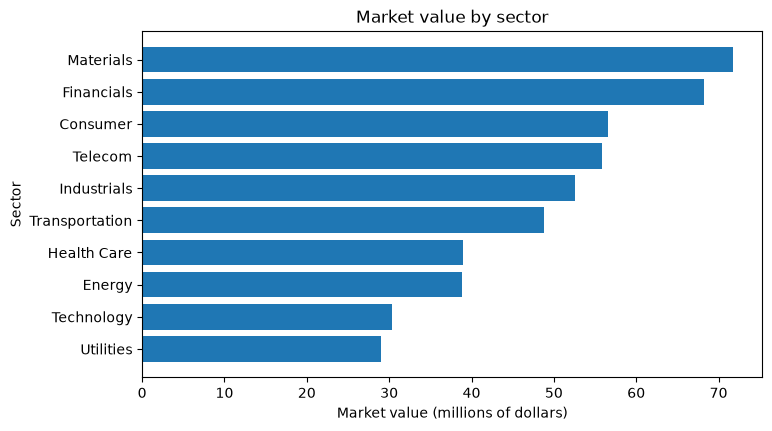

In [26]:
# total market value of each sector, in millions of dollars, smallest first
value_by_sector = (book.groupby('sector')['market_value'].sum() / 1_000_000).sort_values()
print(value_by_sector.round(2))
print('Total:', round(value_by_sector.sum(), 2))

fig, ax = plt.subplots(figsize=(8, 4.5))

# barh() draws horizontal bars, from the bottom of the chart upward
ax.barh(value_by_sector.index, value_by_sector.values)

ax.set_title('Market value by sector')
ax.set_xlabel('Market value (millions of dollars)')
ax.set_ylabel('Sector')

plt.show()

* Materials is the longest bar at 71.70 million dollars, then Financials at 68.22 million. Utilities is the shortest at 29.01 million. The ten bars add up to 490.82 million dollars, the market value of the book.
* `barh()` draws the first row at the bottom, so sorting from smallest to largest puts the largest sector at the top.
* Sectors have no natural order, so sorting by size is the useful order here. Rating buckets do have one, and sorting those by size would have hidden it.
* `market_value` in this file includes accrued interest. Last week's 483.02 million was the value at the clean price.

**Excel side by side.**

| Job | Python | Excel |
| --- | --- | --- |
| Average of one group | `mean_by_bucket['BBB']` | `=AVERAGEIF(U:U, "BBB", M:M)` |
| Averages of all groups | `book.groupby('bucket')['oas'].mean()` | a pivot table: `bucket` in Rows, Average of `oas` in Values |
| Vertical bars | `ax.bar(names, heights)` | Insert, Insert Column or Bar Chart, Clustered Column |
| Horizontal bars | `ax.barh(names, lengths)` | Insert, Insert Column or Bar Chart, Clustered Bar |
| Values on the bars | `ax.bar_label(bars)` | Chart Elements, Data Labels |
| Chart straight from the summary | `sns.barplot(...)` | a PivotChart on the pivot table |

The `AVERAGEIF` formula assumes the bucket in column U of the joined sheet and the OAS in column M. It returns 127.82. A pivot table sorts its row labels as text, so the buckets come out in alphabetical order there too, and the rows are dragged into credit order by hand.

## 11.6 Line Plot

A **line plot** joins points with a line, from left to right. The line says that the x axis has an order and that it makes sense to move along it. The most common x axis on a desk is time, and the Treasury yield case study later this week is all line plots. The holdings file is one date, so here the ordered axis is the rating scale itself: the 18 ratings from AAA to CCC, scored 1 to 18.

Q. What is the median OAS at each rating, and how many bonds is each one based on?

In [27]:
# two statistics of the OAS for each score: the median and the number of bonds
by_score = book.groupby('score')['oas'].agg(['median', 'count'])
print(by_score)

       median  count
score               
1        21.0      2
2        39.0      1
3        27.0      3
4        43.0      4
5        56.0     16
6        63.5     12
7        94.0     28
8       102.0     21
9       126.0     15
10      149.0     26
11      189.0     23
12      218.5     16
13      312.5     10
14      351.5      6
15      520.0      5
16      468.0      7
17      789.0      4
18      547.0      1


* Eighteen rows, one per rating. The median OAS is 21 basis points at score 1 and 789 at score 17.
* The counts matter: scores 2 and 18 have one bond each, and score 7, which is A-, has 28.

Q. Draw the median OAS against the rating.

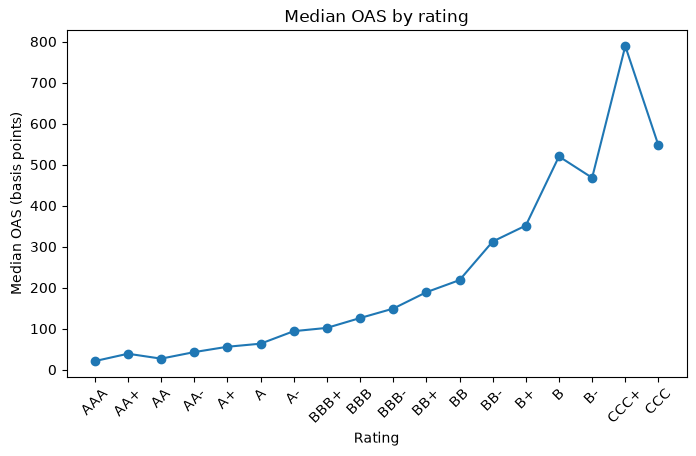

In [28]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.plot() takes the x values and the y values. marker='o' draws a dot at each point.
ax.plot(by_score.index, by_score['median'], marker='o')

# put a tick at every score, and show the rating in place of the number, tilted to fit
ax.set_xticks(ratings['score'], ratings['rating'], rotation=45)

ax.set_title('Median OAS by rating')
ax.set_xlabel('Rating')
ax.set_ylabel('Median OAS (basis points)')

plt.show()

* The line rises slowly through the Investment Grade ratings, from 21 basis points at AAA to 149 at BBB-, and then more steeply, to 789 at CCC+.
* It does not rise at every step. The median at AA, 27, is below the median at AA+, 39. B- at 468 is below B at 520, and CCC at 547 is below CCC+ at 789. The first and the last of those dips involve a rating with a single bond, AA+ and CCC. B and B- have 5 and 7 bonds.
* `set_xticks()` takes the positions of the ticks and, as a second argument, the text to show at each. `rotation=45` tilts the text so that 18 labels fit side by side. The x axis is still the score, 1 to 18. Only the labels changed.
* The dots show where the data is. The line between two dots is only a guide for the eye: there is no rating between BBB and BBB-.

Q. Add the mean OAS as a second line.

score
15    621.60
16    530.14
17    935.75
18    547.00
Name: oas, dtype: float64
   rating  score   oas
65   CCC+     17  1551
17      B     15  1446


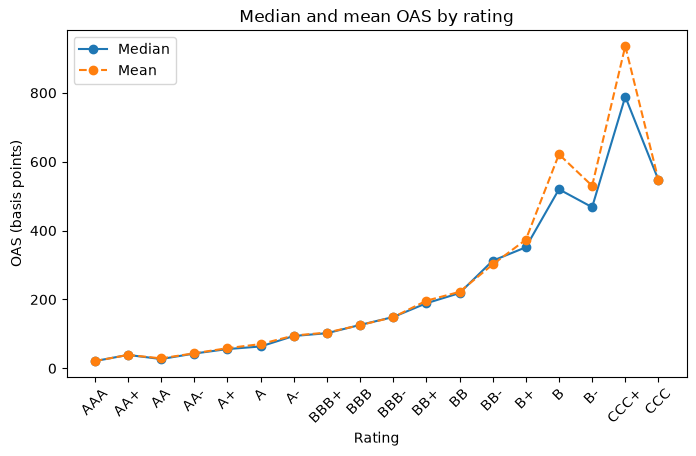

In [29]:
# the mean OAS for each score
mean_by_score = book.groupby('score')['oas'].mean()
print(mean_by_score.round(2).tail(4))

# the two widest bonds in the book, and their ratings
print(book.nlargest(2, 'oas')[['rating', 'score', 'oas']])

fig, ax = plt.subplots(figsize=(8, 4.5))

# two calls to ax.plot() draw two lines on the same axes. label= names each for the legend.
ax.plot(by_score.index, by_score['median'], marker='o', label='Median')
ax.plot(mean_by_score.index, mean_by_score.values, marker='o', linestyle='--', label='Mean')

ax.set_xticks(ratings['score'], ratings['rating'], rotation=45)
ax.legend()

ax.set_title('Median and mean OAS by rating')
ax.set_xlabel('Rating')
ax.set_ylabel('OAS (basis points)')

plt.show()

* The two lines are close together on the left of the chart and separate at the lowest ratings. At B, score 15, the mean is 621.6 basis points against a median of 520, and at CCC+, score 17, it is 935.75 against 789. Each of those two ratings contains one of the two widest bonds in the book, at 1,446 and 1,551 basis points.
* At CCC the lines meet again, at 547. With one bond, the mean and the median are the same number.
* matplotlib gave the second line a new colour. The `linestyle='--'` makes the two lines distinguishable in a black and white printout as well.
* A line plot suits the rating scale because the ratings are ordered. It would not suit the sectors of section 11.5: joining Energy to Financials with a line would suggest a path between them that does not exist.

**Excel side by side.**

| Job | Python | Excel |
| --- | --- | --- |
| Median of one group | `by_score.loc[10, 'median']` | `=MEDIAN(IF(T2:T201=10, M2:M201))` |
| Line plot | `ax.plot(x, y, marker='o')` | Insert, Insert Line or Area Chart, Line with Markers |
| A second line | a second `ax.plot()` | a second column in the selected range, which becomes a second series |
| Legend | `ax.legend()` | Chart Elements, Legend |

The `MEDIAN(IF(...))` formula assumes the score in column T and the OAS in column M. It returns 149, the median at BBB-. In versions of Excel before dynamic arrays it is entered with Ctrl+Shift+Enter.

## 11.7 Scatter Plot

A **scatter plot** draws one point per row, placed by two numeric columns: one along the x axis and one up the y axis. Nothing is counted or averaged, and all 200 bonds are on the chart. A desk uses it to see whether two measures move together, and to spot the bonds that do not follow the others.

Q. Do yield and OAS move together across the book?

Correlation of OAS and yield: 0.99


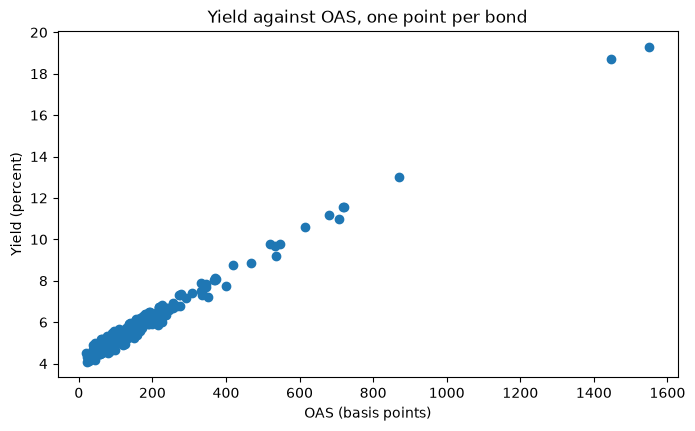

In [30]:
# corr() gives the correlation of two columns: 1 is a perfect rising line, 0 is no straight-line relationship
print('Correlation of OAS and yield:', round(book['oas'].corr(book['yield_pct']), 2))

fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.scatter() takes the x column and the y column
ax.scatter(book['oas'], book['yield_pct'])

ax.set_title('Yield against OAS, one point per bond')
ax.set_xlabel('OAS (basis points)')
ax.set_ylabel('Yield (percent)')

plt.show()

* The points fall close to a straight rising line, and the correlation is 0.99. A bond with a wider OAS has a higher yield.
* That is how the two columns are defined. A bond's yield is a government yield plus its spread, so across one book on one date most of the difference in yield between two bonds is the difference in their spreads.
* Most of the 200 points are crowded into the lower left, and the two widest bonds are alone in the upper right. The same skew as the histogram, seen on both axes.
* **Correlation** is a number between -1 and 1. Near 1, the points lie close to a rising line. Near -1, a falling line. Near 0, there is no straight-line pattern.

Q. Do duration and OAS move together?

Correlation of duration and OAS: -0.11


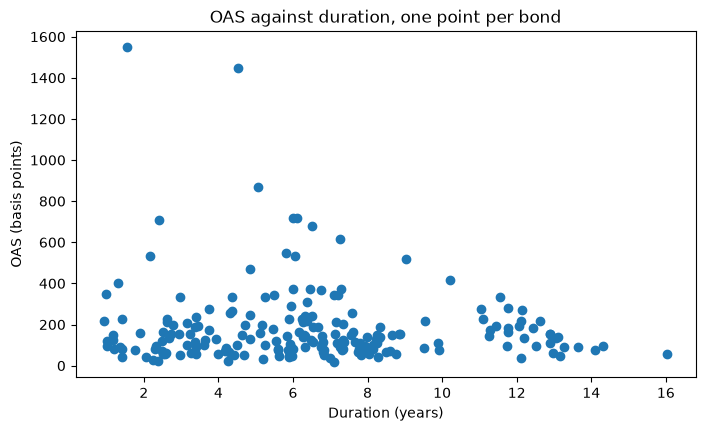

In [31]:
print('Correlation of duration and OAS:', round(book['duration'].corr(book['oas']), 2))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(book['duration'], book['oas'])

ax.set_title('OAS against duration, one point per bond')
ax.set_xlabel('Duration (years)')
ax.set_ylabel('OAS (basis points)')

plt.show()

* A cloud with no line through it. The correlation is -0.11, close to zero. Across the whole book, knowing a bond's duration says very little about its OAS.
* Most points lie below 400 basis points at every duration, from under 1 year to 16 years. Section 11.4 counted 14 bonds above 409.875.

One cloud can hide two groups. seaborn can colour each point by a third column.

Q. Draw the same chart with each point coloured by its grade.

Investment Grade: 0.24
High Yield: -0.1


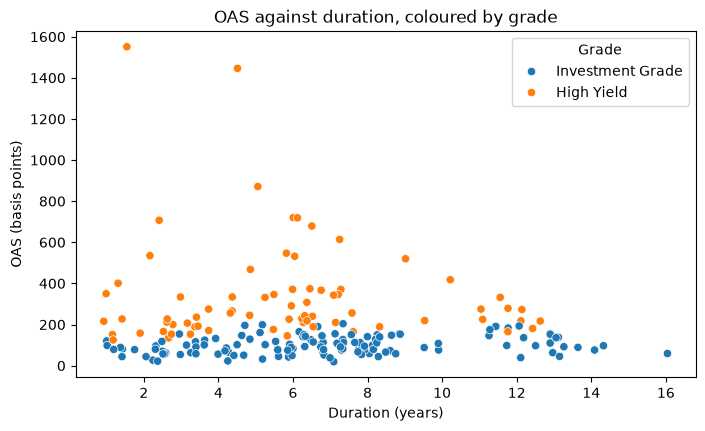

In [32]:
# the correlation within each grade
ig = book[book['grade'] == 'Investment Grade']
hy = book[book['grade'] == 'High Yield']
print('Investment Grade:', round(ig['duration'].corr(ig['oas']), 2))
print('High Yield:', round(hy['duration'].corr(hy['oas']), 2))

fig, ax = plt.subplots(figsize=(8, 4.5))

# hue= names the column that sets the colour of each point. seaborn adds the legend.
sns.scatterplot(data=book, x='duration', y='oas', hue='grade', ax=ax)

# seaborn titles the legend with the column name. This gives it a capital letter.
ax.legend(title='Grade')

ax.set_title('OAS against duration, coloured by grade')
ax.set_xlabel('Duration (years)')
ax.set_ylabel('OAS (basis points)')

plt.show()

* The colours split the cloud into two layers. The Investment Grade points form a flat band along the bottom, none above 204 basis points. The High Yield points sit above them, from 125 up to 1,551.
* Within the Investment Grade bonds the correlation of duration and OAS is 0.24: a mild upward tilt. Within the High Yield bonds it is -0.1. The figure for the whole book, -0.11, described neither group.
* `hue=` is the seaborn argument for colouring by a category. It works in most seaborn functions, and the legend comes with it.
* A correlation describes how two columns of this book line up on this date. It does not say that one causes the other.

**Excel side by side.**

| Job | Python | Excel |
| --- | --- | --- |
| Scatter plot | `ax.scatter(book['oas'], book['yield_pct'])` | select the two columns, then Insert, Insert Scatter (X, Y) or Bubble Chart, Scatter |
| Correlation | `book['oas'].corr(book['yield_pct'])` | `=CORREL(M2:M201, L2:L201)` |
| Colour by group | `hue='grade'` | one data series per grade, each with its own colour |

The `CORREL` formula assumes the OAS in column M and the yield in column L. It returns 0.99. In Excel the first selected column goes on the x axis.

## 11.8 Pair Plot

Two scatter plots answered two questions. With four columns there are six different pairs, and with six columns there are fifteen. A **pair plot** draws every pair at once in a grid, so the first look at a new table takes one line.

Q. Draw every pair among coupon, price, OAS, and duration.

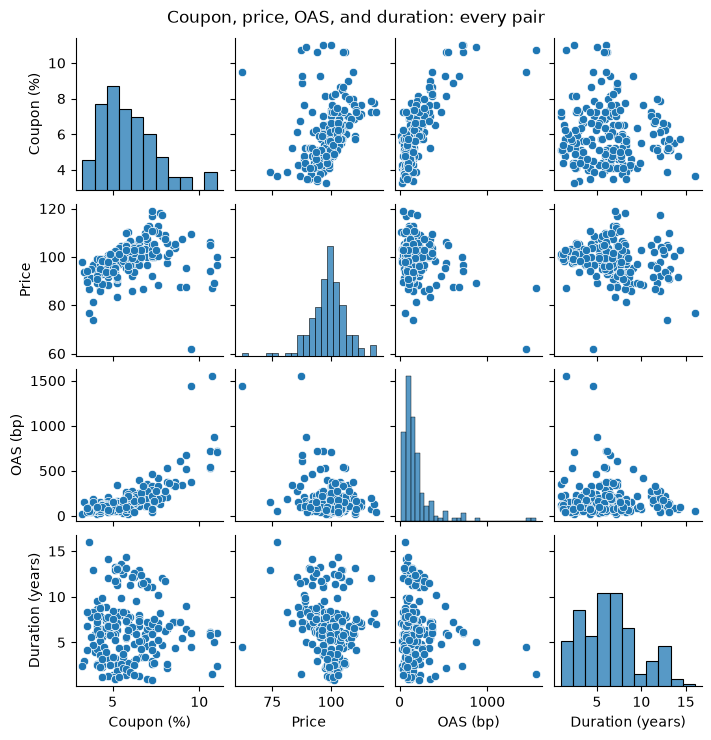

In [33]:
# the four columns, renamed so that each panel is labelled with its unit
pair_data = book[['coupon', 'price', 'oas', 'duration']].rename(columns={
    'coupon': 'Coupon (%)',
    'price': 'Price',
    'oas': 'OAS (bp)',
    'duration': 'Duration (years)',
})

# pairplot() makes its own figure. height= is the size of each panel in inches.
grid = sns.pairplot(pair_data, height=1.8)

# the title goes on the figure, a little above the top row
grid.figure.suptitle('Coupon, price, OAS, and duration: every pair', y=1.02)

plt.show()

* A grid of 16 panels: 4 rows and 4 columns, one for each of the four measures.
* The 4 panels on the diagonal are histograms, because a column plotted against itself would be a straight line and say nothing. The OAS histogram, third on the diagonal, is the one from section 11.3.
* The other 12 panels are scatter plots. Each pair appears twice, once above the diagonal and once below with the axes swapped, so there are 6 different pairs.
* Read along a row. In the OAS row, the panel against coupon rises to the right, and the panel against duration is the flat cloud of section 11.7. The two widest bonds, at 1,446 and 1,551 basis points, stand apart in every panel of that row.
* There is no `fig, ax = plt.subplots()` in this cell. `pairplot()` needs many axes, so it builds the whole figure itself and returns a grid object. The figure is reached through `grid.figure`. Adding `hue='grade'` and the `grade` column would colour the points as in section 11.7.

**Excel side by side.** Excel has no single chart for this. The same picture is six separate Scatter charts, one for each pair of columns, arranged on a sheet. The pair plot is a first look and not a finished chart: it shows which pairs are worth a chart of their own.

## 11.9 Heatmap

A **heatmap** is a table with a colour behind each number: the larger the number, the stronger the colour. The eye finds the dark and light cells before it reads a single figure. A desk uses it on any table where the pattern across the rows and columns matters more than one cell.

The pair plot showed the shape of each pair. One number for each pair, the correlation, fits in a table.

Q. What is the correlation of every pair among six numeric columns?

In [34]:
# corr() on a table gives the correlation of every column with every other
corr_columns = ['coupon', 'price', 'yield_pct', 'oas', 'duration', 'dts']
corr_table = book[corr_columns].corr()

corr_table.round(2)

,coupon,price,yield_pct,oas,duration,dts
coupon,1.00,0.31,0.74,0.74,-0.05,0.66
price,0.31,1.00,-0.32,-0.30,-0.19,-0.33
yield_pct,0.74,-0.32,1.00,0.99,0.01,0.81
oas,0.74,-0.30,0.99,1.00,-0.11,0.75
duration,-0.05,-0.19,0.01,-0.11,1.00,0.40
dts,0.66,-0.33,0.81,0.75,0.40,1.00


* Six rows and six columns, 36 numbers. The diagonal is all 1: each column is perfectly correlated with itself. The table is the same above and below the diagonal, because the correlation of coupon with price is the correlation of price with coupon.
* It takes a while to find the largest and smallest values in 36 numbers.

Q. Draw the table as a heatmap.

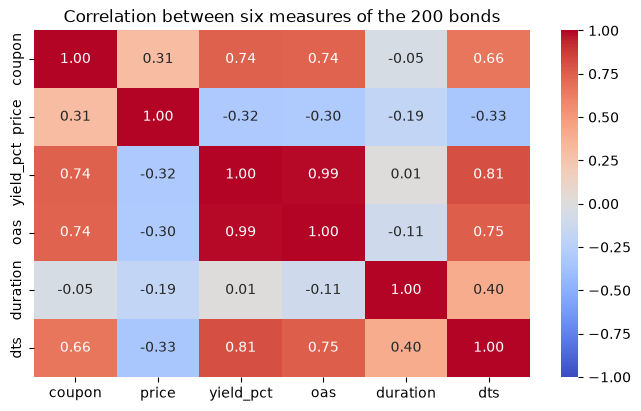

In [35]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# annot=True writes the number in each cell, and fmt='.2f' shows it to two decimal places
# cmap= is the colour scale. vmin and vmax fix its two ends, so that 0 falls in the middle.
sns.heatmap(corr_table, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation between six measures of the 200 bonds')

plt.show()

* Red cells are positive correlations, blue cells are negative, and pale cells are near zero. The bar on the right is the key to the colours.
* The darkest cell off the diagonal is yield against OAS, 0.99, the near-straight line of section 11.7. Coupon is 0.74 with both yield and OAS.
* DTS is duration times spread, and the heatmap shows both parents: 0.75 with OAS and 0.40 with duration.
* The duration row is pale. Its correlation with OAS is -0.11, the cloud of section 11.7, and with coupon it is -0.05.
* Price is mildly negative against yield, OAS, and DTS, at -0.32, -0.30, and -0.33.
* `vmin=-1` and `vmax=1` matter. Without them seaborn stretches the colours between the smallest and largest numbers in this table, and zero would no longer be the pale midpoint.

A heatmap works on any table of numbers. Last week's pivot tables are a natural fit.

Q. How many bonds are in each sector and rating bucket?

In [36]:
# a pivot table of counts: sectors down the side, buckets across the top
# fill_value=0 shows a zero where a sector has no bond in a bucket
bond_counts = pd.pivot_table(book, values='cusip', index='sector', columns='bucket',
                             aggfunc='count', fill_value=0)

# put the columns in credit order
bond_counts = bond_counts[bucket_order]
print('Bonds counted:', bond_counts.sum().sum())

bond_counts

Bonds counted: 200


bucket,AAA,AA,A,BBB,BB,B,CCC
sector,,,,,,,
Consumer,0,2,5,10,3,6,0
Energy,0,0,4,10,0,3,0
Financials,0,3,3,14,4,0,2
Health Care,0,1,7,6,6,0,0
Industrials,0,0,5,7,4,3,1
Materials,0,0,10,3,10,3,0
Technology,0,0,6,1,3,0,2
Telecom,2,0,1,5,12,1,0
Transportation,0,0,10,3,7,0,0


* Ten sectors by seven buckets, and the 70 cells add up to 200 bonds.

Q. Draw it as a heatmap.

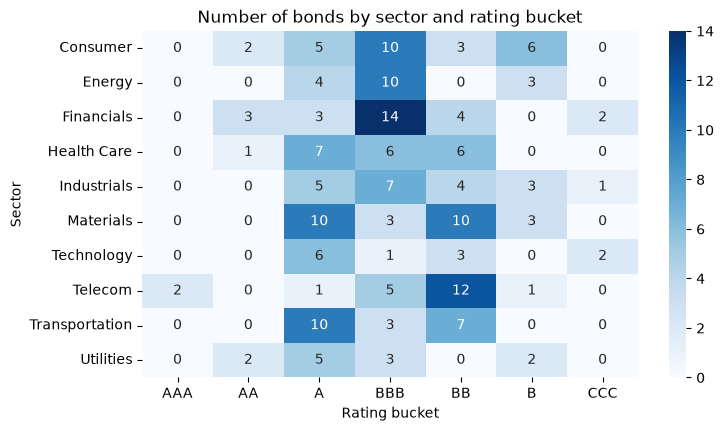

In [37]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# fmt='d' shows whole numbers. Blues runs from white for the lowest count to dark blue for the highest.
sns.heatmap(bond_counts, annot=True, fmt='d', cmap='Blues', ax=ax)

ax.set_title('Number of bonds by sector and rating bucket')
ax.set_xlabel('Rating bucket')
ax.set_ylabel('Sector')

plt.show()

* The darkest cell is Financials BBB with 14 bonds, then Telecom BB with 12. Five cells hold 10 bonds each: Consumer BBB, Energy BBB, Materials A, Materials BB, and Transportation A.
* The middle three columns, A, BBB, and BB, carry most of the colour. The AAA column is white except for one cell: both AAA bonds are in Telecom.
* This is a count of bonds, so every bond weighs the same. A heatmap of market value would use the same code with `values='market_value'` and `aggfunc='sum'`.
* One colour scale suits counts, which start at zero and only go up. The two-colour scale of the correlation heatmap suits numbers that can be negative or positive.

**Excel side by side.**

| Job | Python | Excel |
| --- | --- | --- |
| One correlation | `book['oas'].corr(book['duration'])` | `=CORREL(M2:M201, N2:N201)` |
| The table of counts | `pd.pivot_table(..., aggfunc='count')` | a pivot table: `sector` in Rows, `bucket` in Columns, Count of `cusip` in Values |
| Colour behind the numbers | `sns.heatmap(table, annot=True)` | select the cells, then Home, Conditional Formatting, Color Scales |

Color Scales shades each cell by its value and leaves the number in place, which is what `annot=True` does. The `CORREL` formula assumes the OAS in column M and the duration in column N, and returns -0.11.

## 11.10 Choosing a Chart

Seven charts, and each one answers a different kind of question.

| The question | Chart | matplotlib | seaborn | Excel chart |
| --- | --- | --- | --- | --- |
| How is one numeric column distributed? | Histogram | `ax.hist()` | `sns.histplot()` | Histogram |
| How does that distribution differ between groups? | Box plot | `ax.boxplot()` | | Box and Whisker |
| How does one number compare across categories? | Bar chart | `ax.bar()`, `ax.barh()` | `sns.barplot()` | Clustered Column, Clustered Bar |
| How does a number change along an ordered axis? | Line plot | `ax.plot()` | | Line |
| Do two numeric columns move together? | Scatter plot | `ax.scatter()` | `sns.scatterplot()` | Scatter |
| What do all the pairs look like? | Pair plot | | `sns.pairplot()` | several Scatter charts |
| Where are the large and small cells of a table? | Heatmap | | `sns.heatmap()` | Conditional Formatting, Color Scales |

Whichever chart it is, the habits are the same:

* Work out the numbers first, with `describe()`, `groupby()`, or a count, and check the chart against them.
* Give every chart a title, and every axis a label with its unit.
* Put ratings in credit order. No library does it for you.
* Know how many bonds are behind each bar, box, or point on a line.
* Describe what the chart shows. A chart of this book is a picture of the data and not a view on any bond.

## You Can Now

* Make a figure and an axes, draw on it, and give it a title and labelled axes with units.
* Show the distribution of a column as a histogram, and say why its mean and median differ.
* Read a box plot: the median, the quartiles, the whiskers, and the points beyond them.
* Turn a grouped table into a bar chart, in an order that makes sense for the categories.
* Draw a line along an ordered axis, with a second line and a legend.
* Plot two measures against each other, colour the points by a group, and put a correlation next to the picture.
* Take a first look at every pair of columns with a pair plot, and show a table of numbers as a heatmap.

The next notebook adds more chart types, among them regression plots, violin plots, and interactive charts, and covers customizing how a chart looks.

## Exercises

The lesson's charts were mostly about the OAS. The exercises use the same 200 bonds and ask about columns the lesson did not chart: duration, coupon, and yield. The issuers are invented, and every answer describes the data and is not a view.

Each exercise asks for a chart and for one or two numbers that the chart should agree with. Replace each `...` with your own code, draw the chart in the same cell or a new one, then run the check cell. Give every chart a title and axis labels with units. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports the libraries, loads fresh copies of the two tables, rebuilds `book` and `bucket_order`, and defines `check`, a small function that marks your answers. It prints the shape of the book, (200, 22), and the seven buckets in credit order.

In [38]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# fresh copies of the two tables. In Colab they are read from GitHub.
if os.path.exists('../../data/holdings.csv'):
    data_folder = '../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

holdings = pd.read_csv(data_folder + 'holdings.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')

# the book, rebuilt: the holdings with the score, bucket, and grade of each rating
book = pd.merge(holdings, ratings, on='rating', how='left')
bucket_order = ratings.sort_values('score')['bucket'].unique().tolist()

print(book.shape)
print(bucket_order)

(200, 22)
['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC']


### Exercise 1

Q. Draw a histogram of `duration` with 15 bins. What is the mean duration of the book, rounded to 2 decimal places? How many bonds have a duration above 10 years? Store the answers in **ex1_mean** and **ex1_long**.

In [39]:
ex1_mean = ...
ex1_long = ...

In [40]:
check('Exercise 1 mean', ex1_mean, 6.47)
check('Exercise 1 long bonds', ex1_long, 31)

Exercise 1 mean: not attempted yet
Exercise 1 long bonds: not attempted yet


### Exercise 2

Q. Draw a box plot of `coupon` with one box for each grade. What is the median coupon of the Investment Grade bonds, and of the High Yield bonds? Store the answers in **ex2_ig_median** and **ex2_hy_median**.

In [41]:
ex2_ig_median = ...
ex2_hy_median = ...

In [42]:
check('Exercise 2 Investment Grade', ex2_ig_median, 5.125)
check('Exercise 2 High Yield', ex2_hy_median, 7.0)

Exercise 2 Investment Grade: not attempted yet
Exercise 2 High Yield: not attempted yet


### Exercise 3

Q. Draw a bar chart of the average `duration` of each rating bucket, in credit order. Which bucket has the tallest bar, and how tall is it, rounded to 2 decimal places? Store the answers in **ex3_bucket** and **ex3_height**. The method `idxmax()` returns the label of the largest value in a Series.

In [43]:
ex3_bucket = ...
ex3_height = ...

In [44]:
check('Exercise 3 bucket', ex3_bucket, 'BBB')
check('Exercise 3 height', ex3_height, 7.4)

Exercise 3 bucket: not attempted yet
Exercise 3 height: not attempted yet


### Exercise 4

Q. Draw a scatter plot with `coupon` on the x axis and `yield_pct` on the y axis, with the points coloured by grade. What is the correlation of the two columns, rounded to 2 decimal places? How many bonds have a yield above their coupon? Store the answers in **ex4_corr** and **ex4_above**.

In [45]:
ex4_corr = ...
ex4_above = ...

In [46]:
check('Exercise 4 correlation', ex4_corr, 0.74)
check('Exercise 4 above coupon', ex4_above, 113)

Exercise 4 correlation: not attempted yet
Exercise 4 above coupon: not attempted yet


### Exercise 5: AI check

You ask an AI assistant for a bar chart of the average OAS of each rating bucket, in credit order. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It contains one bug.

Q. Read the code before you run it. How tall should the BBB bar be? The lesson worked it out in section 11.5. Then run the code. Does the chart agree with you?

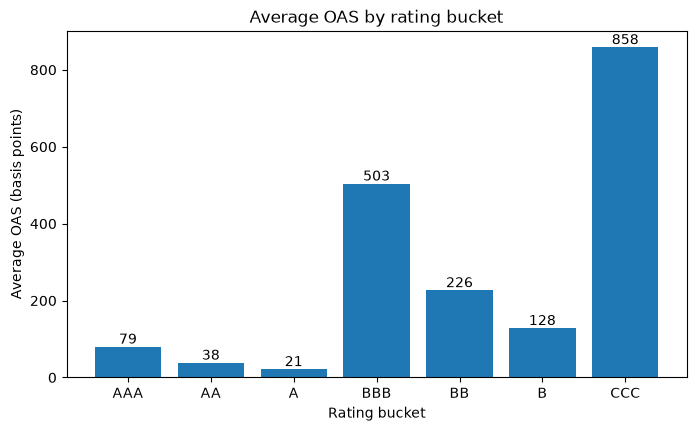

Height of the bar labelled BBB: 503.33


In [47]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
# average OAS of each rating bucket, drawn in credit order
avg_oas = book.groupby('bucket')['oas'].mean()
labels = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC']

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, avg_oas.values)
ax.bar_label(bars, fmt='%.0f')

ax.set_title('Average OAS by rating bucket')
ax.set_xlabel('Rating bucket')
ax.set_ylabel('Average OAS (basis points)')

plt.show()

# the height of the bar that carries the label BBB
ex5_bbb = round(avg_oas.values[labels.index('BBB')], 2)
print('Height of the bar labelled BBB:', ex5_bbb)

Q. Find the bug and fix the code in the cell above, so that the bars are under the right labels and **ex5_bbb** holds the right answer.

In [48]:
check('Exercise 5 BBB bar', ex5_bbb, 127.82)

Exercise 5 BBB bar: not yet. You have 503.33
